# Analyzing Samples with Spatialize
<span style="color: purple;">**This notebook has been tested with `spatialize v1.2.0`**</span>

## Background

Spatial interpolators, like [**Ensemble Spatial Interpolation (ESI)**](./esi_overview.ipynb) produce spatial estimates at *unmeasured* locations based on known values, i.e. at sampled locations. In spatial estimation, Cross-validation (leave-one-out or k-fold) is typically used to see how the same modelling setup performs at the sample locations themselves. Because the cross-validation prediction is itself an ESI ensemble, the held-out sample receives one re-prediction *per partition*, not a single value (we call these the *ESI samples*). For classic model evaluation, the ESI samples would be aggregated to produce an ESI estimate, but `spatialize.spa` provides a novel, alternative application: evaluating the samples themselves.

## Introducing SPA

The SPA module in spatialize employs the cross-validation ESI samples to answer which *individual* samples were predictable from their neighbors and which weren't. A sample the rest of the data predicts well is redundant, it adds little the model didn't already infer. A sample the rest of the data predicts poorly is a surprise: either it holds genuinely new information, or it's a mislogged measurement worth checking. 

For this, the sample's own true value is appended to the ensemble set and a probability model is fit to it, via the [**`FittedModelFactory`**](../utilities/empirical_tools.ipynb) machinery, producing the sample's local **predictive distribution**.

From this fitted distribution, `spa` computes two diagnostics per sample:

- its **entropy** — how uncertain the CV-based prediction was at that location, independent of whether it turned out to be right;
- its own **CDF value** (percentile) — where the true value falls within its own predicted distribution. A value near the tails (close to 0 or 1) means the sample was a surprise relative to what its neighbors predicted; a value near the center means it was unremarkable.

## The SPA Workflow in Spatialize

1. **Run cross-validated posterior estimation** with `cv_sample_pred_posterior(points, values, xi, local_interpolator=..., k=...)`, which takes the same arguments as `esi_nongriddata` plus `k` for leave-one-out (`k=-1`, default) or k-fold cross-validation. It returns a **`PosteriorSampleAnalyzer`**.
2. **Inspect global diagnostics** with `.plot_summary()` (value, percentile, and entropy distributions across all samples) and `.quick_plot_models()` (histogram, PDF, and CDF for a random subset of individual samples).
3. **Rank samples by how surprising they are** with `.rank_samples()`, which assigns each one a category from `level_0` (outside its 99% central entropy interval — most surprising) to `level_4` (inside even the narrowest, 50%, interval — least surprising).
4. **Map the ranking spatially** with `.plot_ranking(samples_ranking)` — a bar chart of category counts next to a map of sample locations colored by category, showing whether unreliable samples cluster (often a data problem) or scatter (expected local variability).


## Example: Ranking Copper Samples
We use the drillhole copper (Cu) grade dataset, included in Spatialize.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from spatialize.data import load_drill_holes_andes_2D
from spatialize.gs.spa import cv_sample_pred_posterior

# the samples included in the spatialize package
samples, locations, _, _ = load_drill_holes_andes_2D()

points = samples[['x', 'y']].values
values = samples[['cu']].values[:, 0]
xi = locations[['x', 'y']].values

### Step 1 — Cross-Validated Posterior with ESI-IDW

`cv_sample_pred_posterior` runs leave-one-out cross-validation (`k=-1`) through the ESI-IDW ensemble and wraps the resulting per-sample posteriors into a **`PosteriorSampleAnalyzer`**.

In [2]:
sample_analyzer = cv_sample_pred_posterior(points, values, xi,
                                           local_interpolator="idw",
                                           k=-1,
                                           n_partitions=300,
                                           alpha=0.8)

finished 100% of 300 iterations ... 

done (elapsed time:  0s)


### Step 2 — Global Diagnostics

`.plot_summary()` gives a first look at the overall behavior of the cross-validated posteriors: the distribution of raw sample values, of their percentiles under their own fitted posteriors, and of their entropies.

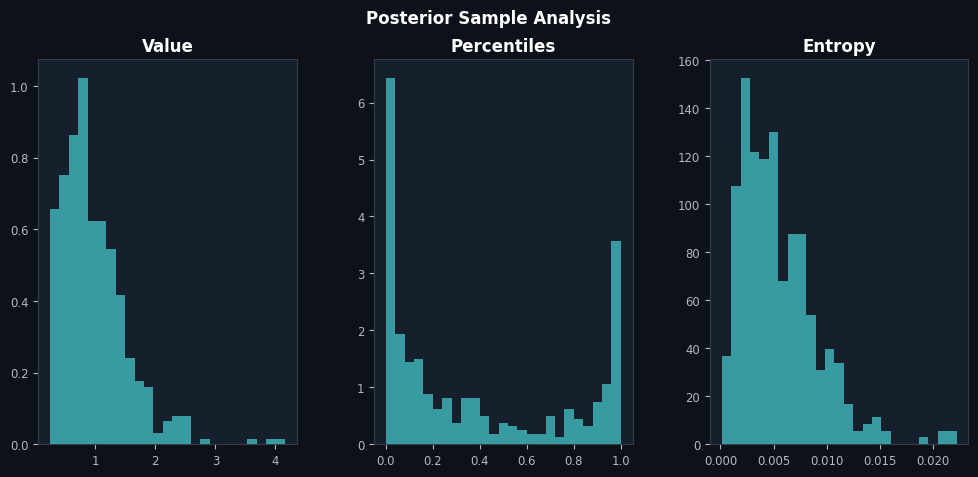

In [3]:
sample_analyzer.plot_summary(figsize=(12, 5), theme='dark')
plt.show()

`.quick_plot_models()` zooms in on a random subset of individual samples, showing the histogram of their cross-validated posterior draws together with the fitted PDF and CDF.

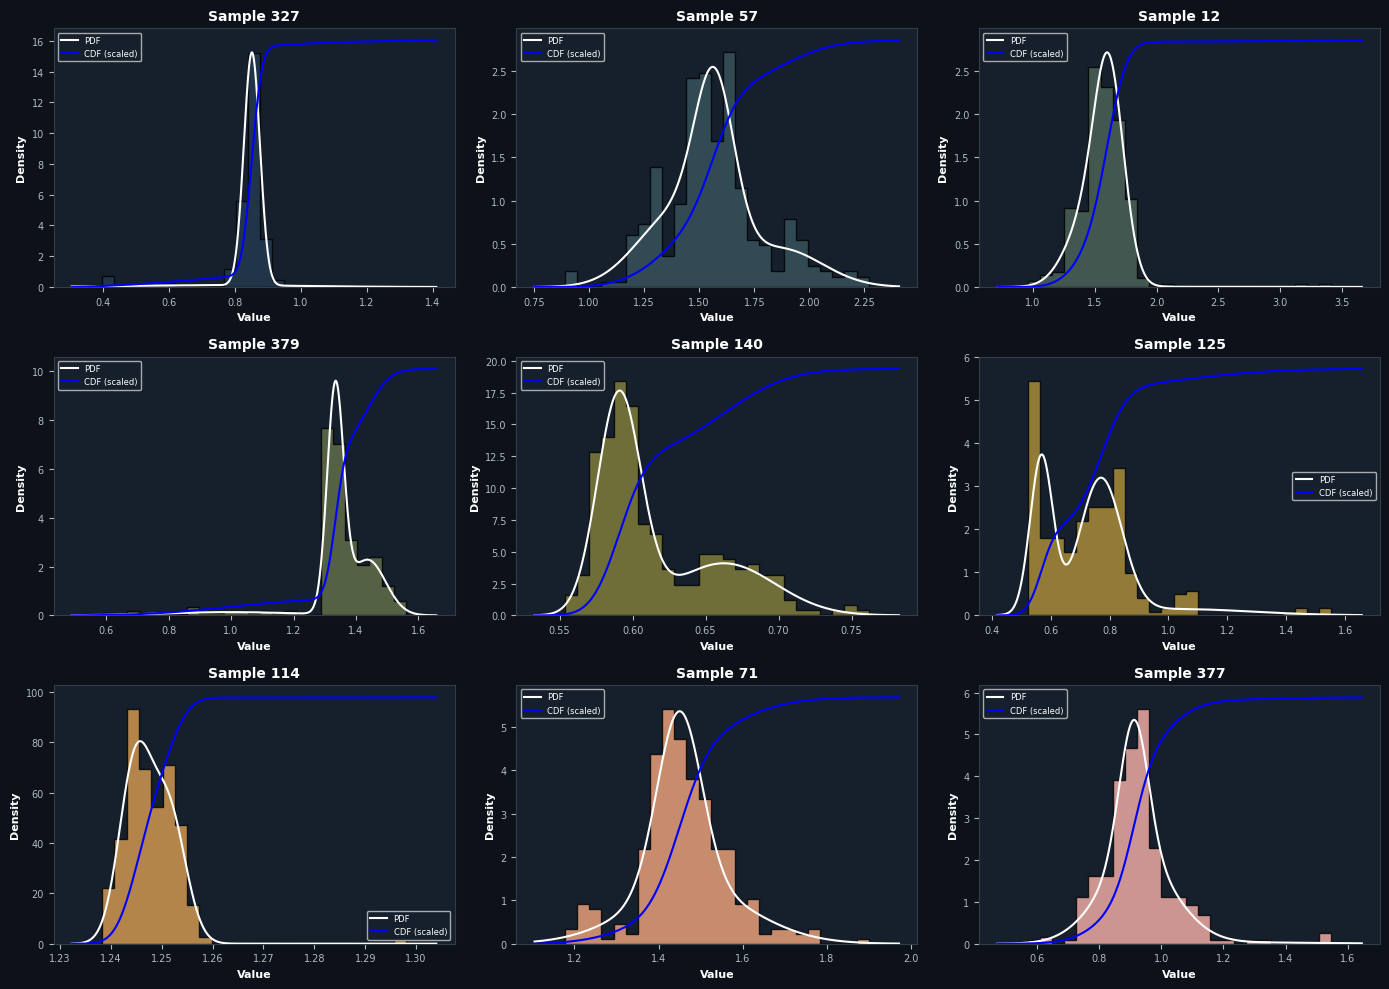

In [4]:
sample_analyzer.quick_plot_models(n_imgs=9, n_cols=3, figsize=(14, 10), theme='dark')
plt.show()

### Step 3 — Ranking and Mapping Uncertain Samples

::: {.callout-note icon=false}

## Usage Notes

`.rank_samples()` can parallelize the per-sample fitting across processes via `n_jobs` (`-1` by default). We use `n_jobs=1` here, since multiprocessing needs a `__main__` guard that notebooks can't provide.
:::

In [5]:
samples_ranking = sample_analyzer.rank_samples(n_jobs=1)
samples_ranking.head()

finished 100% of 400 iterations ... 

done (elapsed time:  1s)


,value,category
0,0.419,level_4
1,1.547,level_2
2,1.138,level_1
3,0.641,level_4
4,0.421,level_2


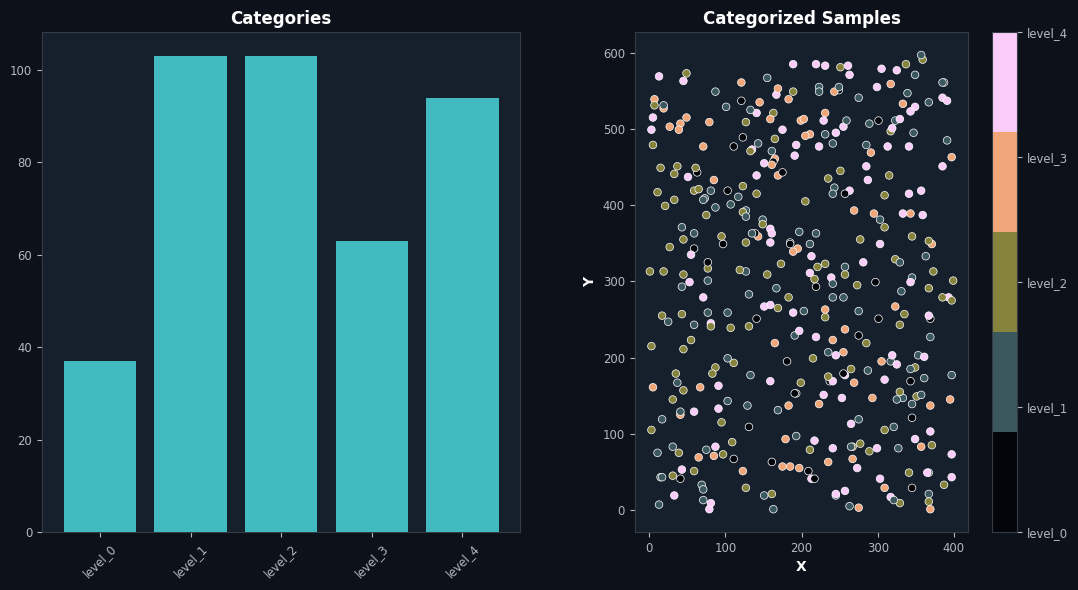

In [6]:
sample_analyzer.plot_ranking(samples_ranking, theme='dark')
plt.show()

Samples in `level_0`/`level_1` are the ones whose true value fell outside the widest central entropy intervals of their own cross-validated posterior — the strongest candidates for a closer look, whether that means a data-quality check or a genuinely interesting local anomaly.


## Further Reading

- **ESI Original**: Egaña, Á.F., Navarro, F., Maleki, M., et al. (2021). *Ensemble Spatial Interpolation: A New Approach to Natural or Anthropogenic Variable Assessment*. Natural Resources Research **30**(5), 3777-3793. https://doi.org/10.1007/s11053-021-09860-2
- **ESA**: Egaña, Á.F., Valenzuela, M.J., Maleki, M. et al. (2025). *Adaptive ensemble spatial analysis*. Scientific Reports **15**, 26599. https://doi.org/10.1038/s41598-025-08844-z
- **Spatialize Library**: Navarro, F., Egaña, Á.F., et al. (2025). *Spatialize v1.0: A Python/C++ Library for Ensemble Spatial Interpolation*. arXiv:2507.17867. https://arxiv.org/abs/2507.17867
- **Spatial Distributional Estimation**: Egaña, Á.F., Díaz, G., Navarro, F., Maleki, M., Sánchez-Pérez, J.F. (2025). *Spatial distributional estimation via ensemble spatial analysis*. AIMS Mathematics **10**(11), 26351-26388. https://doi.org/10.3934/math.20251159